In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from impute import impute_zero

In [2]:
df = pd.read_csv('movie-data/Imdb_Movie_Dataset.csv')

In [3]:
df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,budget,...,original_language,original_title,overview,popularity,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,7/15/2010,825532764,148,False,160000000,...,en,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,11/5/2014,701729206,169,False,165000000,...,en,Interstellar,The adventures of a group of explorers who mak...,140.241,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,7/16/2008,1004558444,152,False,185000000,...,en,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,12/15/2009,2923706026,162,False,237000000,...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,4/25/2012,1518815515,143,False,220000000,...,en,The Avengers,When an unexpected enemy emerges and threatens...,98.082,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [4]:
df.describe()

,id,vote_average,vote_count,revenue,runtime,budget,popularity
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,7.546888e+05,2.041560e+00,2.045584e+01,7.604112e+05,4.822610e+01,2.913232e+05,1.276393e+00
std,4.207457e+05,3.097234e+00,3.315669e+02,1.944925e+07,6.057823e+01,5.319290e+06,7.889555e+00
min,2.000000e+00,0.000000e+00,0.000000e+00,-1.200000e+01,-2.800000e+01,0.000000e+00,0.000000e+00
25%,3.846625e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e-01
50%,8.183790e+05,0.000000e+00,0.000000e+00,0.000000e+00,2.300000e+01,0.000000e+00,6.000000e-01
75%,1.140640e+06,5.000000e+00,1.000000e+00,0.000000e+00,8.900000e+01,0.000000e+00,9.170000e-01
max,1.411041e+06,1.000000e+01,3.449500e+04,5.000000e+09,1.440000e+04,1.000000e+09,2.994357e+03


In [5]:
numeric_columns = ["id","vote_average","vote_count","revenue","runtime","budget","popularity"]

In [6]:
df_numeric = df[[*numeric_columns]]

In [7]:
df_numeric.head()

,id,vote_average,vote_count,revenue,runtime,budget,popularity
0,27205,8.364,34495,825532764,148,160000000,83.952
1,157336,8.417,32571,701729206,169,165000000,140.241
2,155,8.512,30619,1004558444,152,185000000,130.643
3,19995,7.573,29815,2923706026,162,237000000,79.932
4,24428,7.710,29166,1518815515,143,220000000,98.082


In [8]:
df.shape

(1048575, 21)

In [9]:
df_numeric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 7 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   id            1048575 non-null  int64  
 1   vote_average  1048575 non-null  float64
 2   vote_count    1048575 non-null  int64  
 3   revenue       1048575 non-null  int64  
 4   runtime       1048575 non-null  int64  
 5   budget        1048575 non-null  int64  
 6   popularity    1048575 non-null  float64
dtypes: float64(2), int64(5)
memory usage: 56.0 MB


In [10]:
df_numeric[df_numeric["revenue"] < 1]

,id,vote_average,vote_count,revenue,runtime,budget,popularity
325,405774,6.854,9227,0,124,19800000,27.913
328,791373,8.190,9202,0,242,70000000,130.690
395,466282,7.642,8045,0,100,0,38.926
509,454983,7.229,6926,0,105,0,36.649
670,766507,7.762,5821,0,100,65000000,154.579
...,...,...,...,...,...,...,...
1048570,905156,0.000,0,0,0,0,0.600
1048571,905157,0.000,0,0,0,0,0.600
1048572,905158,0.000,0,0,0,0,0.600
1048573,905161,0.000,0,0,0,0,0.600


In [17]:
df[df["id"] == 918555]

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,budget,...,original_language,original_title,overview,popularity,tagline,genres,production_companies,production_countries,spoken_languages,keywords
1042207,918555,Domingo,0.0,0,Released,NaN,2,0,False,2,...,es,Domingo,NaN,0.6,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
imputed_df = impute_zero(df_numeric, )

/home/ryan/Documents/School/Data Science/Data-Science-Project/impute.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2.68041045e+08 5.92793828e+08 2.88702790e+08 ... 1.12636900e+05
 1.12636900e+05 1.12636900e+05]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_imputed.loc[missing_indices, target_col] = imputed_values
/home/ryan/Documents/School/Data Science/Data-Science-Project/impute.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[95400000.  64000000.  63200000.  ...   470524.9   470524.9   470524.9]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_imputed.loc[missing_indices, target_col] = imputed_values


In [13]:
imputed_df[imputed_df["revenue"] < 5]

,id,vote_average,vote_count,revenue,runtime,budget,popularity
10116,14424,6.100,252.0,1.0,117.0,5.0,20.436
12919,18196,6.100,172.0,3.0,92.0,4787380.6,12.674
15616,383809,7.332,128.0,3.0,84.0,162297.0,4.615
15650,13748,5.163,127.0,2.0,90.0,4346203.9,4.963
21332,488621,6.721,77.0,3.0,110.0,4713737.5,7.203
...,...,...,...,...,...,...,...
1040834,913421,0.000,0.0,1.0,52.0,1000.0,0.600
1042207,918555,0.000,0.0,2.0,0.0,2.0,0.600
1044179,917911,0.000,0.0,3.0,8.0,1873.0,0.600
1044685,899159,0.000,0.0,1.0,1.0,1.0,0.840


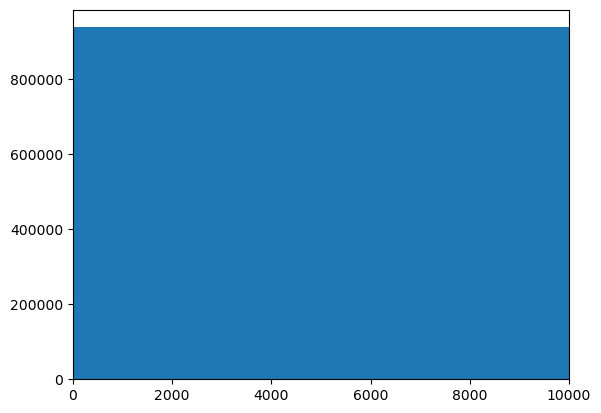

In [26]:
plt.hist(imputed_df["revenue"], bins=100)
plt.xlim(0, 1e4)
plt.show()

In [15]:
imputed_df.describe()

,id,vote_average,vote_count,revenue,runtime,budget,popularity
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,7.546888e+05,2.041560e+00,2.045584e+01,1.174054e+07,4.822610e+01,1.626272e+06,1.276393e+00
std,4.207457e+05,3.097234e+00,3.315669e+02,3.725087e+07,6.057823e+01,7.135667e+06,7.889555e+00
min,2.000000e+00,0.000000e+00,0.000000e+00,-1.200000e+01,-2.800000e+01,1.000000e+00,0.000000e+00
25%,3.846625e+05,0.000000e+00,0.000000e+00,1.126369e+05,0.000000e+00,6.731300e+03,6.000000e-01
50%,8.183790e+05,0.000000e+00,0.000000e+00,4.326900e+05,2.300000e+01,1.463180e+05,6.000000e-01
75%,1.140640e+06,5.000000e+00,1.000000e+00,5.084792e+06,8.900000e+01,4.755505e+05,9.170000e-01
max,1.411041e+06,1.000000e+01,3.449500e+04,5.000000e+09,1.440000e+04,1.000000e+09,2.994357e+03
